# Model Development Lab
In this lab, I build and evaluate regression models to predict car prices.

## Objectives
- Develop simple and multiple linear regression models
- Visualize model fit using regression and residual plots
- Build a polynomial regression model
- Create a pipeline for standardization and regression
- Evaluate models using R² and Mean Squared Error (MSE)

In [1]:
# Import standard libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn tools for regression, preprocessing, and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Make plots display nicely in Colab
%matplotlib inline

## Load the dataset
First, I load the automobile dataset into a pandas DataFrame so I can inspect and model the data.

In [7]:
df = pd.read_csv("automobileEDA.csv")
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


## 1. Simple Linear Regression

In this section, I build a simple linear regression model to predict car price using highway-mpg.

In [8]:
# Create a linear regression model
lm = LinearRegression()

# Define predictor (X) and target (Y)
X = df[['highway-mpg']]
Y = df['price']

# Fit the model
lm.fit(X, Y)

LinearRegression()

In [9]:
# Generate predictions
Yhat = lm.predict(X)

# Show first 5 predictions
Yhat[:5]

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

In [10]:
# Display intercept and slope
print("Intercept:", lm.intercept_)
print("Slope:", lm.coef_[0])

Intercept: 38423.3058581574
Slope: -821.7333783219254


### Model Interpretation

The linear model follows this equation:

price = a + b(highway-mpg)

- a = intercept
- b = slope

This shows how price changes as highway-mpg increases.

## Question 1

In this section, I build another linear regression model using engine-size as the predictor to compare against highway-mpg.

In [11]:
# Create a new linear regression model
lr = LinearRegression()

In [12]:
# Define new predictor and target
X = df[['engine-size']]
Y = df['price']

# Fit the model
lr.fit(X, Y)

LinearRegression()

In [13]:
# Display slope and intercept
print("Intercept:", lr.intercept_)
print("Slope:", lr.coef_[0])

Intercept: -7963.338906281042
Slope: 166.86001569141595


### Model Interpretation

price = a + b(engine-size)

This model shows how price changes based on engine size.

A positive slope means that as engine size increases, price also increases.

## Multiple Linear Regression

In this section, I use multiple predictor variables together to improve the accuracy of price prediction.

In [14]:
# Create a linear regression model
lm = LinearRegression()

# Select multiple predictors
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]

# Fit the model
lm.fit(Z, df['price'])

LinearRegression()

In [15]:
# Display intercept
print("Intercept:", lm.intercept_)

# Display coefficients
print("Coefficients:", lm.coef_)

Intercept: -15806.62462632922
Coefficients: [53.49574423  4.70770099 81.53026382 36.05748882]


In [16]:
# Pair coefficients with feature names
pd.DataFrame({
    "Feature": Z.columns,
    "Coefficient": lm.coef_
})

,Feature,Coefficient
0,horsepower,53.495744
1,curb-weight,4.707701
2,engine-size,81.530264
3,highway-mpg,36.057489


### Model Interpretation

price = a + b1(horsepower) + b2(curb-weight) + b3(engine-size) + b4(highway-mpg)

This model uses multiple variables together to better predict price.

Each coefficient represents the impact of that feature while holding others constant.

## 2. Model Evaluation Using Visualization

In this section, I evaluate model performance using regression plots and residual plots.

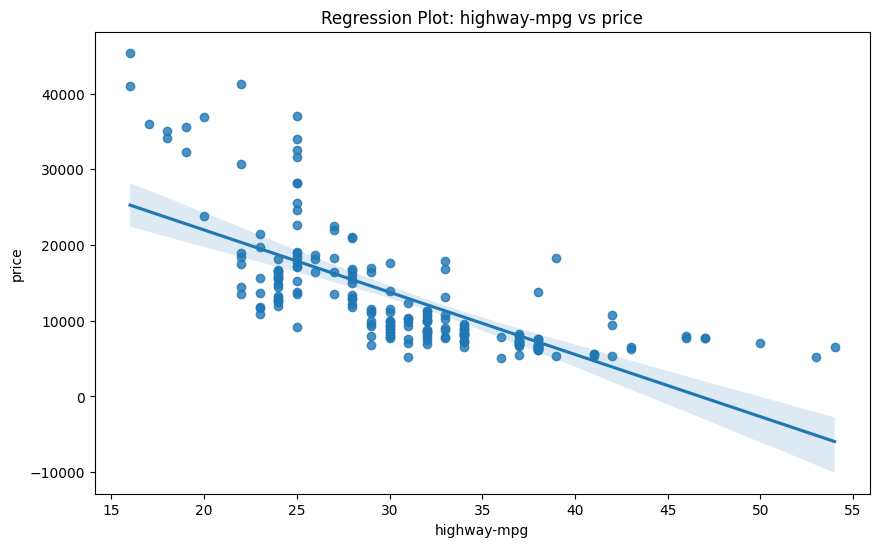

In [17]:
# Regression plot for highway-mpg vs price
plt.figure(figsize=(10, 6))
sns.regplot(x='highway-mpg', y='price', data=df)
plt.title("Regression Plot: highway-mpg vs price")
plt.show()

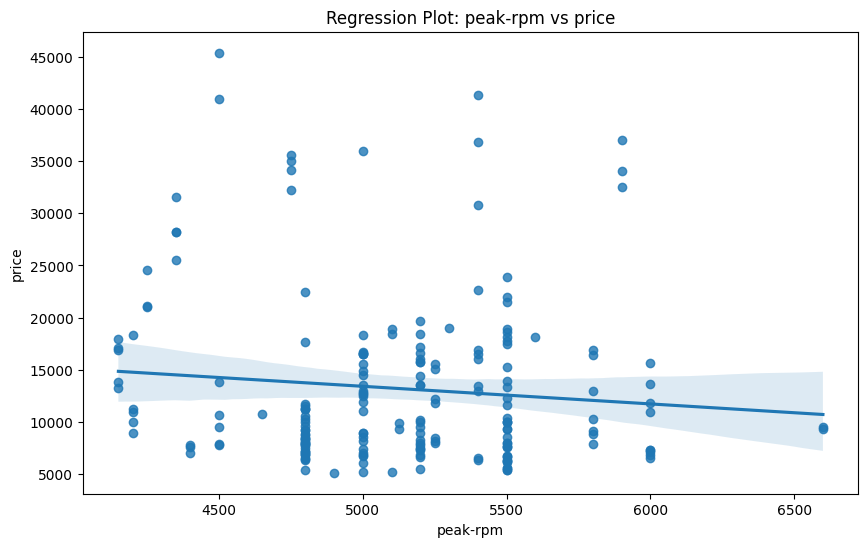

In [18]:
# Regression plot for peak-rpm vs price
plt.figure(figsize=(10, 6))
sns.regplot(x='peak-rpm', y='price', data=df)
plt.title("Regression Plot: peak-rpm vs price")
plt.show()

## Question 3

Highway-mpg is more strongly correlated with price than peak-rpm because the data points are closer to the regression line.

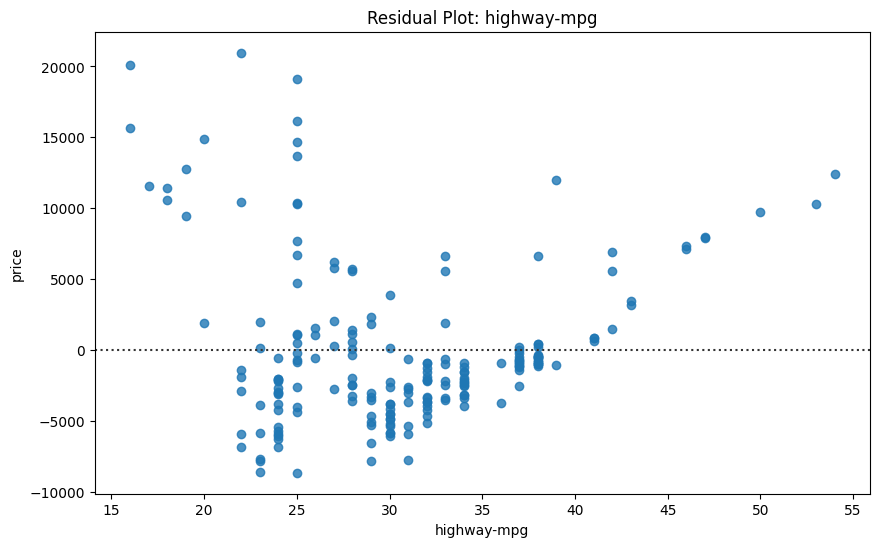

In [19]:
# Residual plot
plt.figure(figsize=(10, 6))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.title("Residual Plot: highway-mpg")
plt.show()

### Residual Plot Interpretation

- If residuals are randomly scattered → linear model is a good fit
- If residuals show a pattern → linear model is not a good fit

## 3. Polynomial Regression

Since the residual plot suggests a non-linear relationship, I will fit a polynomial model to better capture the pattern in the data.

In [20]:
# Define variables
x = df['highway-mpg']
y = df['price']

# Fit a 3rd degree polynomial
f = np.polyfit(x, y, 3)

# Convert to function
p = np.poly1d(f)

# Show equation
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


In [21]:
def PlotPolly(model, independent_variable, dependent_variable, Name):
    x_new = np.linspace(independent_variable.min(), independent_variable.max(), 100)
    y_new = model(x_new)

    plt.figure(figsize=(10, 6))
    plt.plot(independent_variable, dependent_variable, '.', label='Data')
    plt.plot(x_new, y_new, '-', label='Polynomial Fit')
    plt.title(Name)
    plt.xlabel(independent_variable.name)
    plt.ylabel('Price')
    plt.legend()
    plt.show()

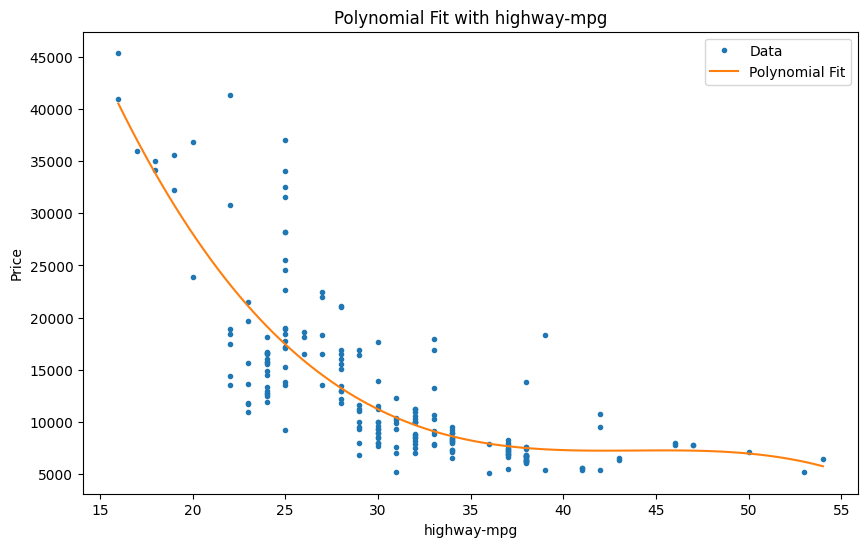

In [22]:
PlotPolly(p, x, y, 'Polynomial Fit with highway-mpg')

## Question 4

Now I create a higher-degree polynomial (11th order) to see how increasing model complexity affects the fit.

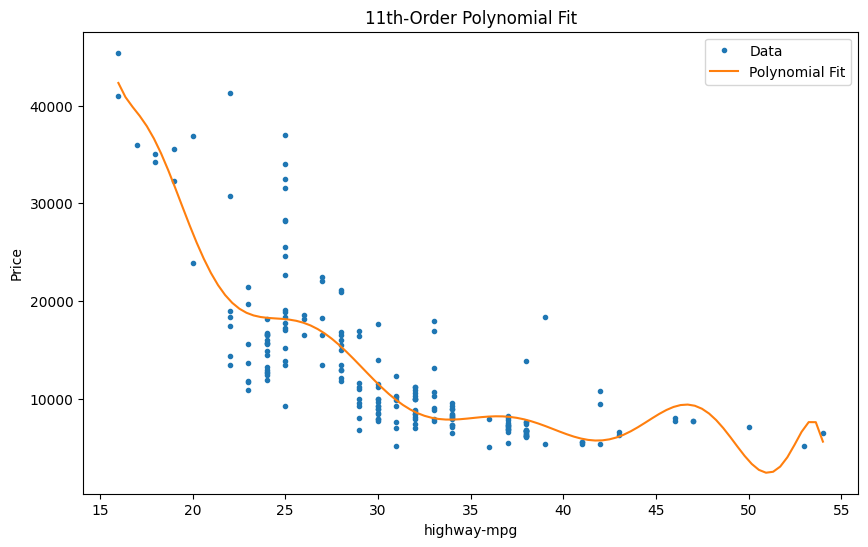

In [23]:
# Fit 11th degree polynomial
f11 = np.polyfit(x, y, 11)
p11 = np.poly1d(f11)

# Plot it
PlotPolly(p11, x, y, '11th-Order Polynomial Fit')

## Polynomial Features

Instead of fitting a polynomial on one variable, I can transform multiple variables into polynomial features to capture more complex relationships.

In [24]:
# Create polynomial features of degree 2
pr = PolynomialFeatures(degree=2)

# Transform the data
Z_pr = pr.fit_transform(Z)

# Compare shapes
print("Original shape:", Z.shape)
print("Transformed shape:", Z_pr.shape)

Original shape: (201, 4)
Transformed shape: (201, 15)


## Pipeline

A pipeline allows me to combine preprocessing steps and modeling into one workflow.

In [25]:
# Create pipeline
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
])

# Fit pipeline
pipe.fit(Z, y)

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [26]:
# Make predictions using pipeline
pipe_pred = pipe.predict(Z)

pipe_pred[:5]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555,
       16136.29619164])

## 4. Measures for In-Sample Evaluation

To evaluate model performance, I use:

- R² (Coefficient of Determination)
- Mean Squared Error (MSE)

R² measures how well the model explains the data.
MSE measures the average squared difference between actual and predicted values.

In [27]:
# Simple Linear Regression using horsepower
lm_slr = LinearRegression()

X = df[['horsepower']]
Y = df['price']

lm_slr.fit(X, Y)

Yhat_slr = lm_slr.predict(X)

print("SLR R²:", lm_slr.score(X, Y))
print("SLR MSE:", mean_squared_error(Y, Yhat_slr))

SLR R²: 0.6554109795391572
SLR MSE: 21654544.398254286


In [28]:
# Multiple Linear Regression evaluation
Yhat_mlr = lm.predict(Z)

print("MLR R²:", lm.score(Z, df['price']))
print("MLR MSE:", mean_squared_error(df['price'], Yhat_mlr))

MLR R²: 0.8093562806577457
MLR MSE: 11980366.87072649


In [29]:
# Polynomial model evaluation
yhat_poly = p(x)

print("Polynomial R²:", r2_score(y, yhat_poly))
print("Polynomial MSE:", mean_squared_error(y, yhat_poly))

Polynomial R²: 0.674194666390652
Polynomial MSE: 20474146.426361218


## Conclusion

- The simple linear regression model provides a basic understanding of the relationship between variables.
- The multiple linear regression model improves prediction accuracy by using multiple features.
- The polynomial model captures non-linear relationships but may overfit if the degree is too high.

Overall, the multiple linear regression model provides the best balance between accuracy and generalization.